# MPOS Figure Generation

Generates Figures 6A, 6C, and S6A from [Bauer, Zali et al. (2026)](https://doi.org/10.64898/2026.03.10.710760) using pre-trained MAVE-NN additive models.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# Custom imports
import mavenn
import logomaker
from collections import Counter
from numpy.lib.stride_tricks import sliding_window_view
from mavenn.src.utils import x_to_ohe

# Set style
plt.style.use("data/24_zali.mplstyle")

logo_kwargs = {
    "fade_below": 0.5,
    "shade_below": 0.5,
    "show_spines": False,
    "center_values": True
}

# Clear figures
!rm -rf figures/*

## Utility Functions

Sliding-window motif scoring, z-score normalization, and ROC curve computation.

In [2]:
def score_regions(seqs: np.ndarray, motif: np.ndarray):
    seqs_ohe = x_to_ohe(x=seqs, alphabet='dna', check_seqs=False, ravel_seqs=False)
    K = motif.shape[0]
    windows = sliding_window_view(x=seqs_ohe, window_shape=K, axis=1)
    fwd_scores = np.einsum('blck,kc->bl', windows, motif)
    rev_scores = np.einsum('blck,kc->bl', windows, motif[::-1,::-1])
    scores = np.concatenate([fwd_scores, rev_scores], axis=1)
    max_scores = np.max(scores,axis=1)
    return max_scores
    
def get_z_scores(pos_seqs, neg_seqs, motif):
    pos_scores = score_regions(seqs=pos_seqs, motif=motif)
    neg_scores = score_regions(seqs=neg_seqs, motif=motif)
    all_scores = np.concatenate([pos_scores, neg_scores])
    mean_score = np.mean(all_scores)
    std_score = np.std(all_scores)
    pos_zs = (pos_scores-mean_score)/std_score
    neg_zs = (neg_scores-mean_score)/std_score
    return pos_zs, neg_zs

def get_roc_curve(pos_values, neg_values):
    scores = np.concatenate([pos_values, neg_values])
    labels = np.concatenate([np.ones_like(pos_values), np.zeros_like(neg_values)])
    desc_score_indices = np.argsort(-scores)
    labels_sorted = labels[desc_score_indices]
    tp_cumsum = np.cumsum(labels_sorted)
    fp_cumsum = np.cumsum(1 - labels_sorted)
    P = len(pos_values)
    N = len(neg_values)
    tpr = np.concatenate([[0], tp_cumsum / P])
    fpr = np.concatenate([[0], fp_cumsum / N])
    auroc = np.trapezoid(tpr, fpr)
    return fpr, tpr, auroc

def filter_seqs_for_length(seqs, name, L=1000):
    lengths = [len(s) for s in seqs]
    counts = Counter(lengths)
    print(f"Length counts for {name}:")
    for k, v in sorted(counts.items()):
        print(f"  {k}: {v}")
    if L is not None:
        filtered_seqs = [s for s in seqs if len(s) == L]
    else:
        filtered_seqs = list(seqs)
    return filtered_seqs

## Figures 6A and S6A: MPOS Additive Models

Sequence logos for OriA-006 and OriC-061 additive models trained on ~15% mutagenized 90 bp origin regions.

Loading model data/NGS-NZ-3477_A1before_yl_A1_plate_yl-0n ...
Model loaded from these files:
	data/NGS-NZ-3477_A1before_yl_A1_plate_yl-0n.pickle
	data/NGS-NZ-3477_A1before_yl_A1_plate_yl-0n.weights.h5
Loading model data/NGS-NZ-3477_C2-out_c2-P ...
Model loaded from these files:
	data/NGS-NZ-3477_C2-out_c2-P.pickle
	data/NGS-NZ-3477_C2-out_c2-P.weights.h5


,A,C,G,T
-9,0.069104,-0.261854,-0.067834,0.260584
-8,0.087878,-0.150408,0.055424,0.007106
-7,-0.064481,-0.035677,-0.076992,0.177150
-6,0.051445,-0.030477,-0.034824,0.013856
-5,0.031321,-0.052080,-0.138586,0.159345
...,...,...,...,...
76,0.054249,-0.089901,0.021780,0.013871
77,0.072000,-0.059018,-0.008911,-0.004071
78,0.126178,-0.089458,-0.045142,0.008422
79,-0.107426,0.024691,-0.006446,0.089182


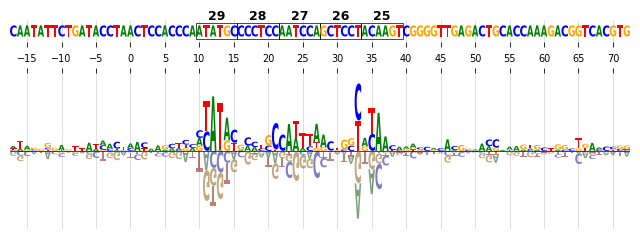

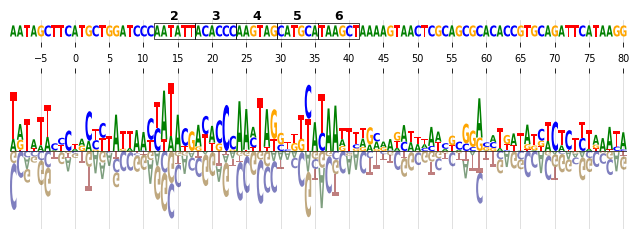

In [3]:
def load_and_plot_mpos_model(model_file_name, 
                             library_file_name, 
                             seq_name, 
                             seq_crop_start, 
                             model_start_pos, 
                             plot_name, 
                             linker_start_pos, 
                             linker_nums,
                             rc_model=False, 
                             rc_seq=False, 
                             figsize=[6.5, 2.5]):
    # Load model
    model = mavenn.load(model_file_name)
    theta_dict = model.get_theta(gauge='uniform')
    theta_lc = theta_dict['theta_lc']
    if rc_model:
        theta_lc = np.fliplr(np.flipud(theta_lc))
    L = len(theta_lc)
    positions = np.arange(L).astype(int) + model_start_pos
    theta_df = pd.DataFrame(theta_lc, columns=model.alphabet)
    theta_df.index = positions

    # Load OriA sequence
    library_df = pd.read_csv(library_file_name)
    seq_full = np.asarray(library_df[library_df['name'] == seq_name]['var_seq'])[0].upper()
    if rc_seq:
        complement_map = str.maketrans("ACGTacgt", "TGCAtgca")
        seq_full = seq_full.translate(complement_map)[::-1]
    seq = seq_full[seq_crop_start:seq_crop_start+L]
    seq_df = logomaker.sequence_to_matrix(seq = seq, to_type = 'probability', alphabet = 'dna')
    seq_df.index = positions

    # Make plots
    fig, axs = plt.subplots(2, 1, figsize=[6.5, 2.5], height_ratios=[1, 7])

    # Plot sequences
    ax = axs[0]
    ylim = np.array([-0.5, 1.5])
    seq_logo = logomaker.Logo(seq_df,  ax=ax, baseline_width=0, show_spines=False)
    xticks = [x for x in positions if x%5==0]
    ax.set_yticks([])
    ax.set_xticks(xticks)
    ax.set_ylim(ylim)
    ax.tick_params(bottom=True, labelbottom=False)  # Show ticks on top, but no labels
    for x in xticks:
        ax.axvline(x, linewidth=0.5, color='lightgray', zorder=-100)

    # Draw a box with no fill and black edge across core_positions and current ylim
    for i, linker_num in enumerate(linker_nums):
        rect_xmin = linker_start_pos - 0.5 + 6*i
        rect_xrange = 6
        rect_ymin = -0.2
        rect_ymax = 1.2
        rect = plt.Rectangle((rect_xmin, rect_ymin),
                            rect_xrange,
                            rect_ymax - rect_ymin,
                            fill=False, edgecolor='black', linewidth=0.5, zorder=-10)
        ax.add_patch(rect)
        ax.text(rect_xmin + rect_xrange/2, 1.3, str(linker_num),
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

    # Plot logo
    ax = axs[1]
    model_logo = logomaker.Logo(theta_df,  ax=ax, **logo_kwargs)
    yrange = max(np.sum(abs(theta_df.values), axis=1))
    ax.set_yticks([])
    ax.set_xticks(xticks)
    ylim = 1.05*np.array(ax.get_ylim())
    ax.set_ylim(ylim)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)  # Show ticks on top, but no labels
    ylim = 1.1*ylim
    ax.set_ylim(ylim)
    for x in xticks:
        ax.axvline(x, linewidth=0.5, color='lightgray', zorder=-100)

    plt.tight_layout(h_pad=0.8)
    plt.savefig(plot_name+".pdf")
    plt.savefig(plot_name+".png", dpi=300)
    
    return theta_df
    
### Fig. 6A: OriA sequence and model
theta_df = load_and_plot_mpos_model(
    model_file_name = "data/NGS-NZ-3477_A1before_yl_A1_plate_yl-0n",
    library_file_name = "data/ORI_A_library_2024-06-13_13_22_23.012484.csv",
    seq_name = 'ori_A_wt',
    seq_crop_start = 19,
    model_start_pos = -17,
    plot_name = 'figures/fig6A_OriA_model',
    linker_start_pos = 10,
    linker_nums = [29, 28, 27, 26, 25],
    rc_model = True,
    rc_seq = True
)

### Fig. S6A: OriC sequence and model
load_and_plot_mpos_model(
    model_file_name = "data/NGS-NZ-3477_C2-out_c2-P",
    library_file_name = "data/ORI_C_library_2024-06-13_13_22_23.186347.csv",
    seq_name = 'ori_C_wt',
    seq_crop_start = 20,
    model_start_pos = -9,
    plot_name = 'figures/figS6C_OriC_model',
    linker_start_pos = 12,
    linker_nums = [2, 3, 4, 5, 6]
)

## Figure 6C: ROC Analysis

Evaluates predictive power of MPOS-derived motifs by scoring EdU-seq peaks vs. random genomic regions (*Y. lipolytica*) and OriDB origins vs. random regions (*S. cerevisiae*).

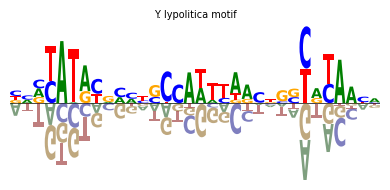

In [4]:
# Plot cropped logo
yl_motif_df = theta_df.loc[8:39].copy()

# plot logos
fig, ax = plt.subplots(1, 1, figsize=[4, 2])
logo = logomaker.Logo(yl_motif_df, ax=ax, **logo_kwargs)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Y. lypolitica motif')
plt.tight_layout()

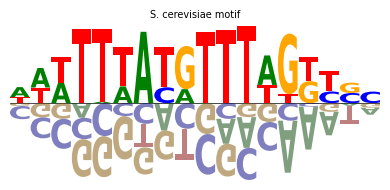

In [5]:
# Get S. cerevisiae origin motif
sc_theta_df = pd.read_table("data/model.mi.exp8_ars416_wt.txt", index_col = "pos")
sc_theta_df.rename({"val_A": "A", "val_C": "C", "val_G": "G", "val_T": "T"}, axis = 1, inplace = True)
sc_motif_df = sc_theta_df.loc[16:33]

# plot logos
fig, ax = plt.subplots(1, 1, figsize=[4, 2])
logo = logomaker.Logo(sc_motif_df, ax=ax, **logo_kwargs)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('S. cerevisiae motif')
plt.tight_layout()

In [6]:
## Load sequences for ROC analysis and check that they are the correct length
yl_pos_seqs = pd.read_csv("data/peakset3_sequence_matches.csv")['seq'].values
yl_neg_seqs = pd.read_csv("data/peakset3_sequence_controls.csv")['seq'].values
sc_pos_seqs = pd.read_csv("data/oriDB_confirmed_ARSs_1000bp.csv")['seq'].values
sc_neg_seqs = pd.read_csv("data/saccharomyces_control_seqs_10000bp.csv")['seq'].values
yl_pos_seqs = filter_seqs_for_length(yl_pos_seqs, "yl_pos_seqs")
yl_neg_seqs = filter_seqs_for_length(yl_neg_seqs, "yl_neg_seqs")
sc_pos_seqs = filter_seqs_for_length(sc_pos_seqs, "sc_pos_seqs")
sc_neg_seqs = filter_seqs_for_length(sc_neg_seqs, "sc_neg_seqs")


Length counts for yl_pos_seqs:
  1000: 623
  1868: 1
  1898: 1
  1909: 1
  1922: 1
  1958: 1
  1992: 1
Length counts for yl_neg_seqs:
  1000: 623
  1868: 1
  1898: 1
  1909: 1
  1922: 1
  1958: 1
  1992: 1
Length counts for sc_pos_seqs:
  948: 1
  1000: 409
Length counts for sc_neg_seqs:
  1000: 410


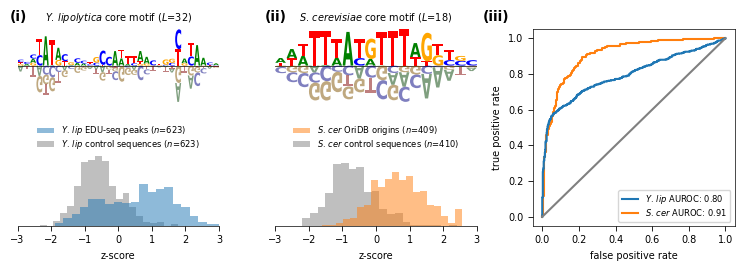

In [7]:
# Create figure with 3 panels side by side

import matplotlib.gridspec as gridspec
from matplotlib.pyplot import axvline
fig = plt.figure(figsize=(7.5, 2.8))
gs = gridspec.GridSpec(2,3, height_ratios=[.4,.6])

def plot_hist(ax, pos_zs, neg_zs, label_pos, label_neg, color_pos, color_neg, ylim = (0, 1), xlim = (-3, 3)):
    ax.hist(pos_zs, label = label_pos, bins = 20, alpha = 0.5, color = color_pos, density=True)
    ax.hist(neg_zs, label = label_neg, bins = 20, alpha = 0.5, color = color_neg, density=True, zorder=-1)
    ax.legend(loc='upper center', frameon=False)
    ax.set_xlabel("z-score")
    ax.set_ylabel(None)
    ax.set_yticks([])
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(False)
    
# yl motif
ax = fig.add_subplot(gs[0,0])
logo = logomaker.Logo(yl_motif_df, ax=ax, **logo_kwargs)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title(rf"$\it{{Y.\,lipolytica}}$ core motif ($L$={len(yl_motif_df)})")

# sc motif
ax = fig.add_subplot(gs[0,1])
logo = logomaker.Logo(sc_motif_df, ax=ax, **logo_kwargs)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title(rf"$\it{{S.\,cerevisiae}}$ core motif ($L$={len(sc_motif_df)})")
    
# Panel A - Y. lipolytica histogram
ax = fig.add_subplot(gs[1,0])
yl_pos_zs, yl_neg_zs = get_z_scores(yl_pos_seqs, yl_neg_seqs, yl_motif_df.values)
pos_label = fr"$\it{{Y.\,lip}}$ EDU-seq peaks ($n$={len(yl_pos_seqs)})"
neg_label = fr"$\it{{Y.\,lip}}$ control sequences ($n$={len(yl_neg_seqs)})"
plot_hist(ax, yl_pos_zs, yl_neg_zs, pos_label, neg_label, "C0", "gray")
ax.set_ylim(0, 1.1)

# Panel B - S. cerevisiae histogram
ax = fig.add_subplot(gs[1,1])
sc_pos_zs, sc_neg_zs = get_z_scores(sc_pos_seqs, sc_neg_seqs, sc_motif_df.values)
pos_label = fr"$\it{{S.\,cer}}$ OriDB origins ($n$={len(sc_pos_seqs)})"
neg_label = fr"$\it{{S.\,cer}}$ control sequences ($n$={len(sc_neg_seqs)})"
plot_hist(ax, sc_pos_zs, sc_neg_zs, pos_label, neg_label, "C1", "gray")
ax.set_ylim(0, 1.1)

# Panel C - ROC curves
ax = fig.add_subplot(gs[:,2])
sc_fpr, sc_tpr, sc_auroc = get_roc_curve(sc_pos_zs, sc_neg_zs)
yl_fpr, yl_tpr, yl_auroc = get_roc_curve(yl_pos_zs, yl_neg_zs)
ax.plot(yl_fpr, yl_tpr, label = r"$\it{Y.\,lip}$ AUROC: " + f"{yl_auroc:.2f}", color = "C0")
ax.plot(sc_fpr, sc_tpr, label = r"$\it{S.\,cer}$ AUROC: " + f"{sc_auroc:.2f}", color = "C1", zorder=-1)
ax.plot([0, 1], [0, 1], color = "gray")
ax.legend()
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.tick_params(axis='both')

# Add (i), (ii), (iii) labels to the upper left of each subplot
annotations = [
    ("(i)",0.01),
    ("(ii)",0.35),
    ("(iii)",0.64)
]

for label, xloc in annotations:
    fig.text(x=xloc,y=0.95,s=label, fontsize=10, fontweight='bold', va='top', ha='left')

fig.tight_layout()
fig_name = "figures/fig6C_ROC_curves"
fig.savefig(f"{fig_name}.pdf")
fig.savefig(f"{fig_name}.png", dpi=300)